In [1]:
# Step 1: Upload the financials.csv file from your computer
from google.colab import files
uploaded = files.upload()

Saving financials.csv to financials.csv


In [2]:
# Step 2: Load and inspect the data
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load the CSV
df = pd.read_csv('financials.csv')

# Basic inspection
print("Shape:", df.shape)
print("\nColumn Names:")
print(df.columns.tolist())
print("\nFirst 5 rows:")
df.head()

Shape: (700, 16)

Column Names:
['Segment', 'Country', 'Product', 'Discount Band', 'Units Sold', 'Manufacturing Price', 'Sale Price', 'Gross Sales', 'Discounts', ' Sales', 'COGS', 'Profit', 'Date', 'Month Number', 'Month Name', 'Year']

First 5 rows:


,Segment,Country,Product,Discount Band,Units Sold,Manufacturing Price,Sale Price,Gross Sales,Discounts,Sales,COGS,Profit,Date,Month Number,Month Name,Year
0,Government,Canada,Carretera,NaN,1618.5,3,20,32370.0,0.0,32370.0,16185.0,16185.0,01-01-14,1,January,2014
1,Government,Germany,Carretera,NaN,1321.0,3,20,26420.0,0.0,26420.0,13210.0,13210.0,01-01-14,1,January,2014
2,Midmarket,France,Carretera,NaN,2178.0,3,15,32670.0,0.0,32670.0,21780.0,10890.0,06-01-14,6,June,2014
3,Midmarket,Germany,Carretera,NaN,888.0,3,15,13320.0,0.0,13320.0,8880.0,4440.0,06-01-14,6,June,2014
4,Midmarket,Mexico,Carretera,NaN,2470.0,3,15,37050.0,0.0,37050.0,24700.0,12350.0,06-01-14,6,June,2014


In [3]:
# Step 3: Clean the data

# Check for missing values
print("Missing values per column:")
print(df.isnull().sum())

# Fill missing Discount Band with 'None'
df['Discount Band'] = df['Discount Band'].fillna('None')

# Strip spaces from column names
df.columns = df.columns.str.strip()

# Convert Date to datetime
df['Date'] = pd.to_datetime(df['Date'])

# Extract Year and Month for analysis
df['Year'] = df['Date'].dt.year
df['Month'] = df['Date'].dt.month

print("\n✅ Data cleaned successfully!")
print("Missing values after cleaning:")
print(df.isnull().sum())

Missing values per column:
Segment                 0
Country                 0
Product                 0
Discount Band          53
Units Sold              0
Manufacturing Price     0
Sale Price              0
Gross Sales             0
Discounts               0
 Sales                  0
COGS                    0
Profit                  0
Date                    0
Month Number            0
Month Name              0
Year                    0
dtype: int64

✅ Data cleaned successfully!
Missing values after cleaning:
Segment                0
Country                0
Product                0
Discount Band          0
Units Sold             0
Manufacturing Price    0
Sale Price             0
Gross Sales            0
Discounts              0
Sales                  0
COGS                   0
Profit                 0
Date                   0
Month Number           0
Month Name             0
Year                   0
Month                  0
dtype: int64


/tmp/ipykernel_1407/449467318.py:14: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['Date'] = pd.to_datetime(df['Date'])


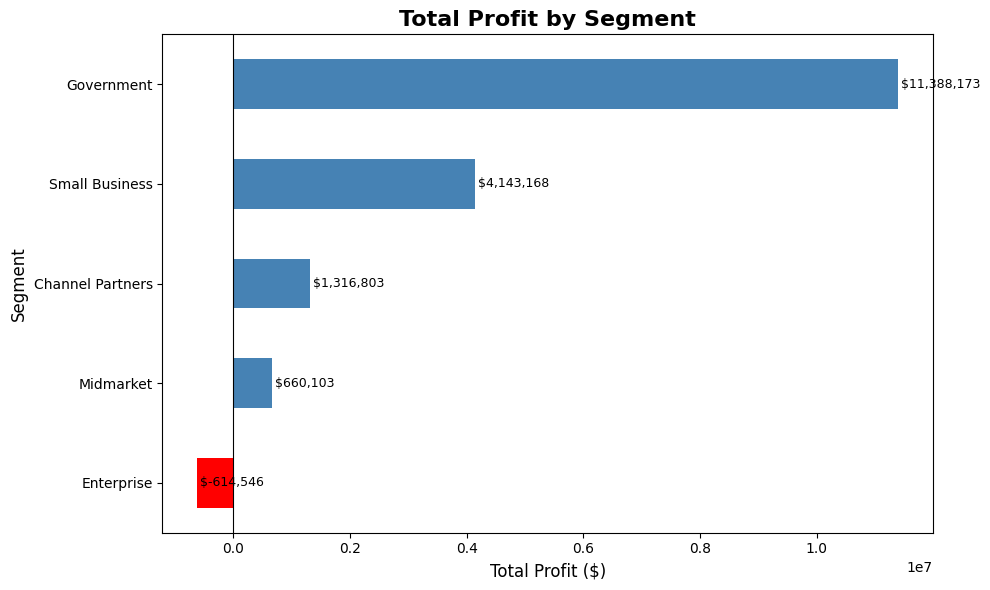

✅ Chart saved!


In [4]:
# Step 4: Segment Profitability Analysis
fig, ax = plt.subplots(figsize=(10, 6))

segment_profit = df.groupby('Segment')['Profit'].sum().sort_values()

colors = ['red' if x < 0 else 'steelblue' for x in segment_profit]

segment_profit.plot(kind='barh', ax=ax, color=colors)

ax.set_title('Total Profit by Segment', fontsize=16, fontweight='bold')
ax.set_xlabel('Total Profit ($)', fontsize=12)
ax.set_ylabel('Segment', fontsize=12)
ax.axvline(x=0, color='black', linewidth=0.8)

# Add value labels
for i, v in enumerate(segment_profit):
    ax.text(v + 50000, i, f'${v:,.0f}', va='center', fontsize=9)

plt.tight_layout()
plt.savefig('segment_profit.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Chart saved!")

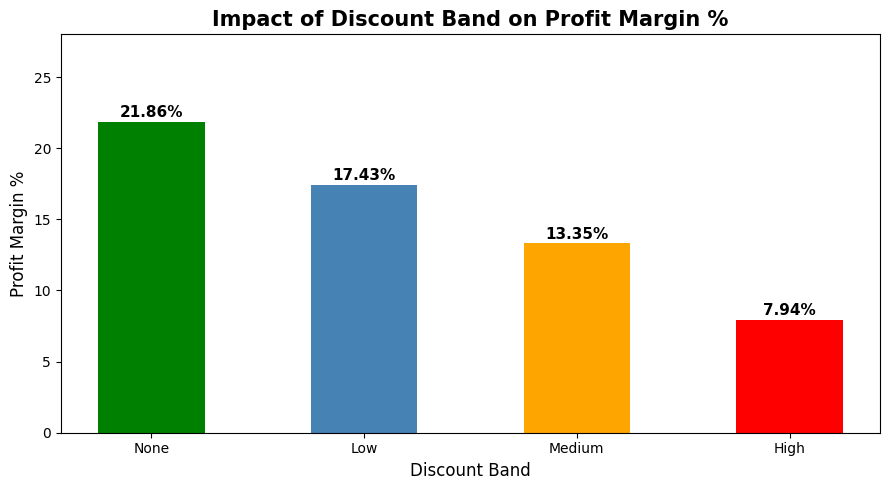

✅ Chart saved!


In [5]:
# Step 5: Discount Impact on Profit Margin
fig, ax = plt.subplots(figsize=(9, 5))

# Calculate profit margin % by discount band
discount_analysis = df.groupby('Discount Band').agg(
    Total_Profit=('Profit', 'sum'),
    Total_Sales=('Gross Sales', 'sum')
).reset_index()

discount_analysis['Profit_Margin_Pct'] = (
    discount_analysis['Total_Profit'] / discount_analysis['Total_Sales'] * 100
).round(2)

# Order from best to worst margin
order = ['None', 'Low', 'Medium', 'High']
discount_analysis['Discount Band'] = pd.Categorical(
    discount_analysis['Discount Band'], categories=order, ordered=True
)
discount_analysis = discount_analysis.sort_values('Discount Band')

colors = ['green', 'steelblue', 'orange', 'red']
bars = ax.bar(discount_analysis['Discount Band'],
              discount_analysis['Profit_Margin_Pct'],
              color=colors, width=0.5)

# Add value labels on bars
for bar, val in zip(bars, discount_analysis['Profit_Margin_Pct']):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.3,
            f'{val}%', ha='center', fontsize=11, fontweight='bold')

ax.set_title('Impact of Discount Band on Profit Margin %',
             fontsize=15, fontweight='bold')
ax.set_xlabel('Discount Band', fontsize=12)
ax.set_ylabel('Profit Margin %', fontsize=12)
ax.set_ylim(0, 28)

plt.tight_layout()
plt.savefig('discount_impact.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Chart saved!")

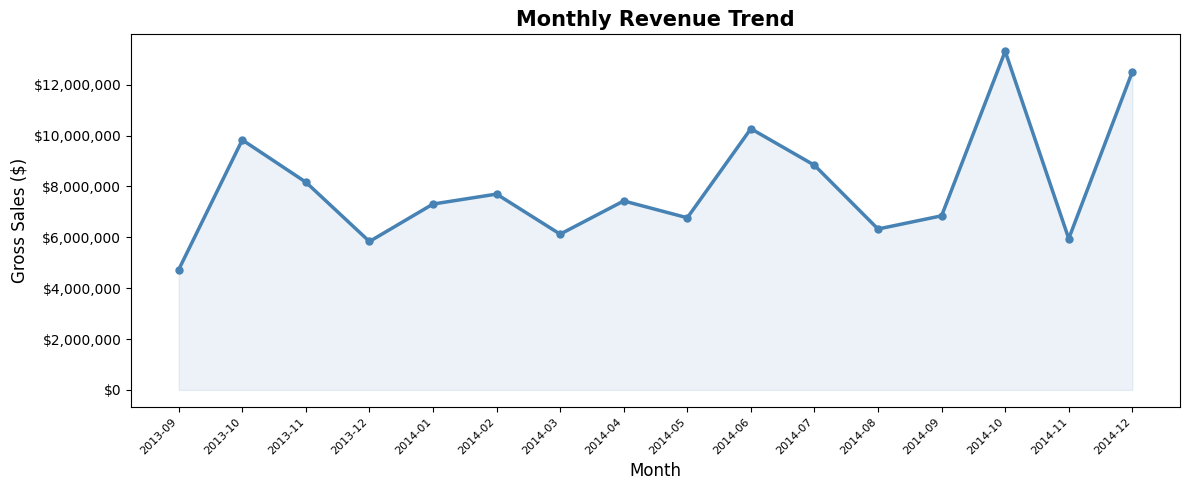

✅ Chart saved!


In [6]:
# Step 6: Monthly Revenue Trend
fig, ax = plt.subplots(figsize=(12, 5))

monthly = df.groupby(['Year', 'Month Number'])['Gross Sales'].sum().reset_index()
monthly['Period'] = monthly['Year'].astype(str) + '-' + monthly['Month Number'].astype(str).str.zfill(2)
monthly = monthly.sort_values('Period')

ax.plot(monthly['Period'], monthly['Gross Sales'],
        marker='o', linewidth=2.5, color='steelblue', markersize=5)

ax.fill_between(range(len(monthly)), monthly['Gross Sales'],
                alpha=0.1, color='steelblue')

ax.set_xticks(range(len(monthly)))
ax.set_xticklabels(monthly['Period'], rotation=45, ha='right', fontsize=8)
ax.set_title('Monthly Revenue Trend', fontsize=15, fontweight='bold')
ax.set_xlabel('Month', fontsize=12)
ax.set_ylabel('Gross Sales ($)', fontsize=12)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'${x:,.0f}'))

plt.tight_layout()
plt.savefig('monthly_trend.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Chart saved!")

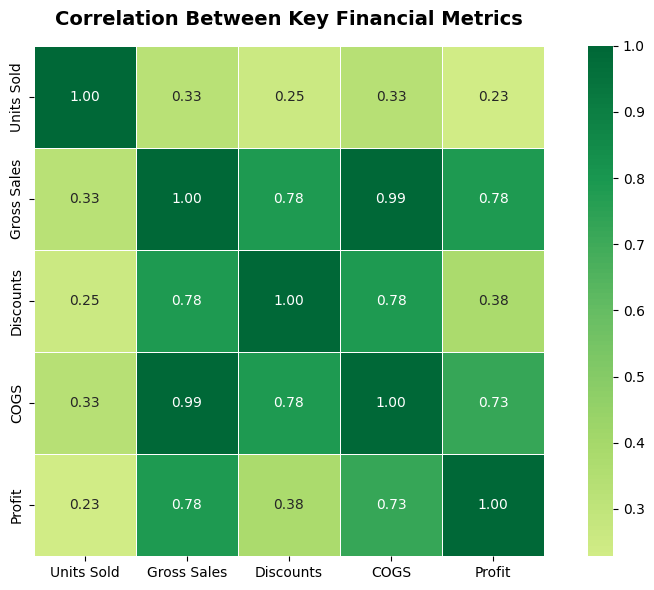

✅ Chart saved!


In [7]:
# Step 7: Correlation Heatmap
fig, ax = plt.subplots(figsize=(9, 6))

# Select numeric columns for correlation
numeric_cols = df[['Units Sold', 'Gross Sales', 'Discounts', 'COGS', 'Profit']]
correlation = numeric_cols.corr()

sns.heatmap(correlation,
            annot=True,
            fmt='.2f',
            cmap='RdYlGn',
            center=0,
            square=True,
            linewidths=0.5,
            ax=ax)

ax.set_title('Correlation Between Key Financial Metrics',
             fontsize=14, fontweight='bold', pad=15)

plt.tight_layout()
plt.savefig('correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Chart saved!")

In [8]:
# Step 8: Key Business Summary
print("=" * 50)
print("   FINANCIAL REVENUE ANALYTICS — KEY FINDINGS")
print("=" * 50)

total_revenue = df['Gross Sales'].sum()
total_profit = df['Profit'].sum()
overall_margin = (total_profit / total_revenue * 100)

print(f"\n📊 OVERALL PERFORMANCE")
print(f"   Total Revenue:  ${total_revenue:,.0f}")
print(f"   Total Profit:   ${total_profit:,.0f}")
print(f"   Overall Margin: {overall_margin:.2f}%")

print(f"\n🏆 BEST PERFORMING SEGMENT")
best = df.groupby('Segment')['Profit'].sum().idxmax()
best_val = df.groupby('Segment')['Profit'].sum().max()
print(f"   {best}: ${best_val:,.0f}")

print(f"\n⚠️  WORST PERFORMING SEGMENT")
worst = df.groupby('Segment')['Profit'].sum().idxmin()
worst_val = df.groupby('Segment')['Profit'].sum().min()
print(f"   {worst}: ${worst_val:,.0f}")

print(f"\n🌍 BEST COUNTRY BY MARGIN")
country_margin = (df.groupby('Country')['Profit'].sum() /
                  df.groupby('Country')['Gross Sales'].sum() * 100)
best_country = country_margin.idxmax()
print(f"   {best_country}: {country_margin.max():.2f}%")

print(f"\n💰 TOP PRODUCT BY REVENUE")
top_product = df.groupby('Product')['Gross Sales'].sum().idxmax()
top_val = df.groupby('Product')['Gross Sales'].sum().max()
print(f"   {top_product}: ${top_val:,.0f}")

print(f"\n🎯 DISCOUNT IMPACT")
no_discount = (df[df['Discount Band']=='None']['Profit'].sum() /
               df[df['Discount Band']=='None']['Gross Sales'].sum() * 100)
high_discount = (df[df['Discount Band']=='High']['Profit'].sum() /
                 df[df['Discount Band']=='High']['Gross Sales'].sum() * 100)
print(f"   No Discount Margin:   {no_discount:.2f}%")
print(f"   High Discount Margin: {high_discount:.2f}%")
print(f"   Margin Lost:          {no_discount - high_discount:.2f}%")

print("\n" + "=" * 50)
print("✅ Analysis Complete!")

   FINANCIAL REVENUE ANALYTICS — KEY FINDINGS

📊 OVERALL PERFORMANCE
   Total Revenue:  $127,931,598
   Total Profit:   $16,893,702
   Overall Margin: 13.21%

🏆 BEST PERFORMING SEGMENT
   Government: $11,388,173

⚠️  WORST PERFORMING SEGMENT
   Enterprise: $-614,546

🌍 BEST COUNTRY BY MARGIN
   Germany: 14.77%

💰 TOP PRODUCT BY REVENUE
   Paseo: $35,611,662

🎯 DISCOUNT IMPACT
   No Discount Margin:   21.86%
   High Discount Margin: 7.94%
   Margin Lost:          13.92%

✅ Analysis Complete!


In [9]:
# Download all charts to your computer
from google.colab import files
files.download('segment_profit.png')
files.download('discount_impact.png')
files.download('monthly_trend.png')
files.download('correlation_heatmap.png')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>